This notebook runs **normative modeling** of **average structural connectivity** as a function of **age** and stratified by **sex**. This enables the build of **normative charts of structural connectivity in healthy aging**, embracing both diversity and uncertainty from a cohort of 1000 healthy subjects. We show only the best fit model, for inter and intra- hemishpheric subsets of the structural connetivity.


In [1]:
import warnings
#removing annoying warnings related to pymc dependencies in pcntoolkit 
warnings.filterwarnings("ignore", category=FutureWarning)

import os 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
plt.rcParams.update({'axes.labelsize':14, 'axes.titlesize':16})
import pickle
import pcntoolkit as ptk  
import arviz as az
from itertools import product


from funcs import *

## Loading the data

Here a .json containing demographic data of subjects and their SC matrices

In [2]:
cwd = os.getcwd()

In [3]:
sc_df = pd.read_json('SC_df.json')

In [4]:
sc_df.isna().sum()

ID_Visit     0
SubjectID    0
Age          1
Sex          0
SC           0
SClog10      0
dtype: int64

In [5]:
sc_df = sc_df.dropna()
sc_df['SC'] = sc_df['SC'].apply(np.array)
sc_df['SClog10'] = sc_df['SClog10'].apply(np.array)

In [6]:
sc_df['Mean_SC'] = sc_df['SC'].apply(np.mean)
sc_df['Mean_SClog10'] = sc_df['SClog10'].apply(np.mean)

We separate SC values in two: the inter-hemispheric connectivity and the intra-hemispheric connectivity. 

In [7]:
n_nodes = sc_df['SC'][0].shape[0]
Mask = np.zeros((n_nodes, n_nodes), dtype='int')
inter_ = np.array(list(product(np.arange(0, n_nodes//2), np.arange(n_nodes//2, n_nodes))))
Mask[inter_[:, 0], inter_[:, 1]] = 1
Mask[inter_[:, 1], inter_[:, 0]] = 1
inter_i = np.where(Mask == 1)
intra_i = np.where(Mask == 0)
sc_df['Mean_inter_SC'] = sc_df['SC'].apply(lambda x: np.mean(x[inter_i]))
sc_df['Mean_intra_SC'] = sc_df['SC'].apply(lambda x: np.mean(x[intra_i]))

In [8]:
import seaborn as sns

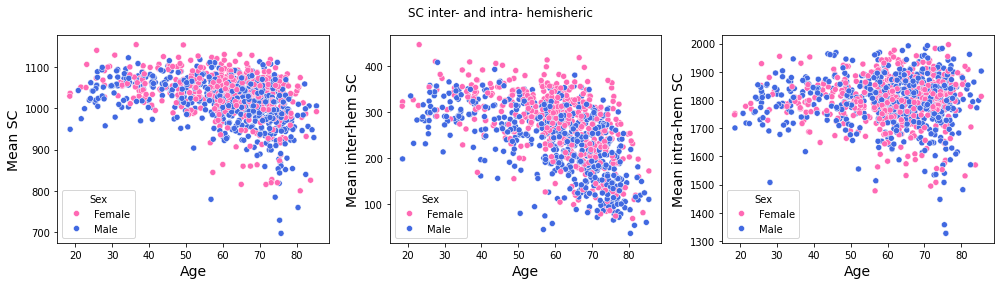

In [9]:
fig, ax = plt.subplots(ncols=3, figsize=(14, 4), sharex=True)
sns.scatterplot(sc_df, x='Age', y='Mean_SC', hue='Sex', palette=['hotpink', 'royalblue'], ax=ax[0])
ax[0].set(ylabel='Mean SC')
sns.scatterplot(sc_df, x='Age', y='Mean_inter_SC', hue='Sex', palette=['hotpink', 'royalblue'], ax=ax[1])
ax[1].set(ylabel='Mean inter-hem SC')
sns.scatterplot(sc_df, x='Age', y='Mean_intra_SC', hue='Sex', palette=['hotpink', 'royalblue'], ax=ax[2]) 
ax[2].set(ylabel='Mean intra-hem SC')
for a in ax.flatten() :
    a.set_xlabel('Age')
fig.suptitle('SC inter- and intra- hemisheric')
fig.tight_layout()
plt.show()

In [10]:
sc_fem = sc_df[sc_df['Sex']=='Female']
sc_male = sc_df[sc_df['Sex']=='Male']

In [11]:
models_dict = {'name': [], 'inscaler':[], 'outscaler':[], 'object': [], 'y': [], 'sex': []}

In [12]:
x_str = 'Age' ; y_str = 'Mean_SC'

In [13]:
models_name = ['gamlss_sig_eps']*2
models_args = [{'likelihood':'SHASHo2', 
                'linear_sigma':'True', 
                'linear_epsilon':'True'}]*2

In [14]:
for i, sc in enumerate([sc_fem, sc_male]) :
    nm, inscaler, outscaler = hbr_fit(sc, 
                                      x_str, 
                                      y_str, 
                                      fit_suffix_str=models_name[i], 
                                      n_chains=2, 
                                      n_warmup=1000, 
                                      n_samples=1000,
                                      model_type='bspline',
                                      **models_args[i])
    
    models_dict['name'].append(models_name[i])
    models_dict['inscaler'].append(inscaler)
    models_dict['outscaler'].append(outscaler)
    models_dict['object'].append(nm)
    models_dict['y'].append(y_str)
    models_dict['sex'].append(['Female', 'Male'][i])

Processing data in /media/tng/3771af5d-6826-432e-8c86-960e3cef1d6c/tng/nina/1000brains/Pseudo/regression/reg_data/Mean_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, delta]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 61 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Processing data in /media/tng/3771af5d-6826-432e-8c86-960e3cef1d6c/tng/nina/1000brains/Pseudo/regression/reg_data/Mean_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, delta]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 63 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


## Inter-hemispheric SC

In [15]:
x_str = 'Age' ; y_str = 'Mean_inter_SC'

In [16]:
models_name = ['gamlss_sig_eps']*2
models_args = [{'likelihood':'SHASHo2', 
                'linear_sigma':'True', 
                'linear_epsilon':'True'}]*2

In [17]:
for i, sc in enumerate([sc_fem, sc_male]) :
    nm, inscaler, outscaler = hbr_fit(sc, 
                                      x_str, 
                                      y_str, 
                                      fit_suffix_str=models_name[i], 
                                      n_chains=2, 
                                      n_warmup=1000, 
                                      n_samples=1000,
                                      model_type='bspline',
                                      **models_args[i])
    
    models_dict['name'].append(models_name[i])
    models_dict['inscaler'].append(inscaler)
    models_dict['outscaler'].append(outscaler)
    models_dict['object'].append(nm)
    models_dict['y'].append(y_str)
    models_dict['sex'].append(['Female', 'Male'][i])

Processing data in /media/tng/3771af5d-6826-432e-8c86-960e3cef1d6c/tng/nina/1000brains/Pseudo/regression/reg_data/Mean_inter_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, delta]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 47 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Processing data in /media/tng/3771af5d-6826-432e-8c86-960e3cef1d6c/tng/nina/1000brains/Pseudo/regression/reg_data/Mean_inter_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, delta]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 62 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


## Intra-hemispheric SC

In [18]:
x_str = 'Age' ; y_str = 'Mean_intra_SC'

In [19]:
models_name = ['gamlss_sig']*2
models_args = [{'likelihood':'SHASHo2', 
                'linear_sigma':'True'}]*2

In [20]:
for i, sc in enumerate([sc_fem, sc_male]) :
    nm, inscaler, outscaler = hbr_fit(sc, 
                                      x_str, 
                                      y_str, 
                                      fit_suffix_str=models_name[i], 
                                      n_chains=2, 
                                      n_warmup=1000, 
                                      n_samples=1000,
                                      model_type='bspline',
                                      **models_args[i])
    
    models_dict['name'].append(models_name[i])
    models_dict['inscaler'].append(inscaler)
    models_dict['outscaler'].append(outscaler)
    models_dict['object'].append(nm)
    models_dict['y'].append(y_str)
    models_dict['sex'].append(['Female', 'Male'][i])

Processing data in /media/tng/3771af5d-6826-432e-8c86-960e3cef1d6c/tng/nina/1000brains/Pseudo/regression/reg_data/Mean_intra_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, epsilon, delta]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 42 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Processing data in /media/tng/3771af5d-6826-432e-8c86-960e3cef1d6c/tng/nina/1000brains/Pseudo/regression/reg_data/Mean_intra_SC.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, epsilon, delta]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 48 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


# Plot quantiles

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


...

Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

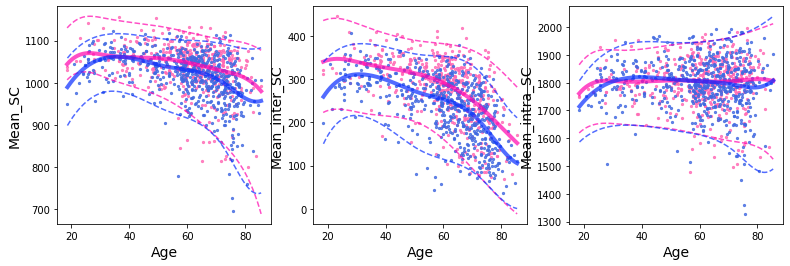

In [67]:
fig, ax = plt.subplots(ncols=3, figsize=(13, 4))
for i in range(0, len(models_dict['object'])-1, 2) :
    y_str = models_dict['y'][i]
    nm_fem = models_dict['object'][i]
    nm_male = models_dict['object'][i+1]
    inscaler_fem = models_dict['inscaler'][i]
    outscaler_fem = models_dict['outscaler'][i] 
    outscaler_fem.fit_transform(sc_fem[y_str])
    inscaler_male = models_dict['inscaler'][i+1]
    outscaler_male = models_dict['outscaler'][i+1]
    outscaler_male.fit_transform(sc_male[y_str])
    plot_quantiles(nm_fem, sc_fem, 'Age', y_str, 
                   inscaler_fem, outscaler_fem, 
                   n_qs=2, by_qs=2, ax=ax[i//2], ptscolor='hotpink', qcolor='#ff03af')
    plot_quantiles(nm_male, sc_male, 'Age', y_str, 
                   inscaler_male, outscaler_male, 
                   n_qs=2, by_qs=2, ax=ax[i//2], ptscolor='royalblue', qcolor='#082dff')


In [68]:
ax[0].set(ylabel='Mean SC')
ax[1].set(ylabel='Mean SC inter-hemespheric')
ax[2].set(ylabel='Mean SC intra-hemispheric')

ax[0].text(18, 
           710, 
           r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x)$',
          size=13)

ax[1].text(18, 
           10, 
           r'$y \sim SHASH(\mu, \sigma, \epsilon, \delta)$' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x)$',
          size=13)

ax[2].text(18, 
           1340, 
           r'$y \sim N(\mu,\sigma)$,' + '\n' + r'$\mu = f_1(x), \sigma = f_2(x)$',
          size=13)

fig.tight_layout()

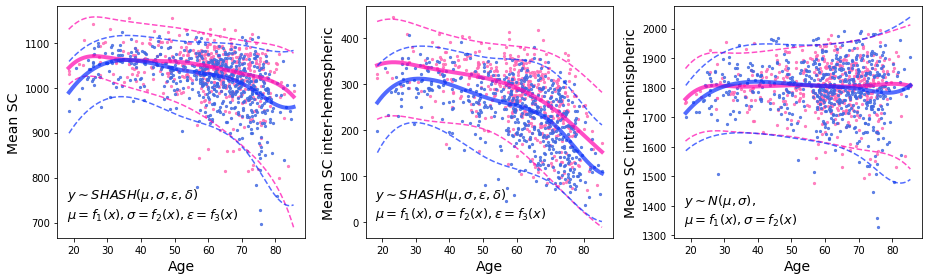

In [69]:
fig

In [70]:
for fmt in ['.png', '.eps', '.svg', '.pdf'] :
    fig.savefig('SC_sex' + fmt, bbox_inches='tight')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


# Packages info

In [71]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Fri Apr 25 2025

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.34.0

seaborn   : 0.13.2
numpy     : 1.26.4
arviz     : 0.20.0
matplotlib: 3.9.2
pcntoolkit: 0.29.post1
pandas    : 2.2.3
logging   : 0.5.1.2

Watermark: 2.4.3

